# Session 9 · A loss harness that is correct and observable

The assignment hands us four lines:

```python
hidden = model(tokens)
logits = output_head(hidden)
loss = cross_entropy(logits[:, :-1].reshape(-1, vocab_size),
                     tokens[:, 1:].reshape(-1))
```

They compute *a* number. They do not say which position predicts which token, which pairs are allowed
to count, what the sum is divided by, or whether the logits must exist all at once. This notebook makes
each of those a named, printed, testable decision, then adds a second head that predicts token `t+2`.

Runs top to bottom on Colab (GPU or CPU) or a laptop. Every section calls the matching script in
`experiments/`, so the numbers here are the numbers in `results/` and in the README.

**Part 1**: 1 shapes · 2 shift, as strings · 3 padding · 4 packing · 5 perplexity · 6 tied vs untied ·
7 peak memory. **Part 2**: the `t+2` head.

## 0 · Setup

In [1]:
import os, sys, subprocess, pathlib
REPO = "https://github.com/amukka/ERA_V5.git"
SUB = "session9_LossFunctions_Outputs"
if not pathlib.Path("src/losses.py").exists():                      # not already inside the folder
    if not pathlib.Path(SUB).exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO, "_repo"], check=True)
        os.replace(f"_repo/{SUB}", SUB)
    os.chdir(SUB)
sys.path.insert(0, os.getcwd())

import torch, importlib
from IPython.display import Markdown, Image, display
from src.train import pick_device
print("cwd   :", os.getcwd())
print("torch :", torch.__version__, "| device:", pick_device())

def show(name, figure=True, md=True):
    """Run experiment `name`, then display the write-up it produced."""
    mod = importlib.import_module(f"experiments.{name}")
    out = mod.main(verbose=False)
    if md:
        display(Markdown(pathlib.Path(f"results/{name}.md").read_text()))
    if figure and pathlib.Path(f"results/{name}.png").exists():
        display(Image(f"results/{name}.png"))
    return out

cwd   : /Users/srinivasmukka/SchoolOfAI/ERA_V5/ERA_V5/session9_LossFunctions_Outputs
torch : 2.13.0 | device: mps


## The harness

`src/losses.py` is the assignment's four lines with every implicit decision written out:

| decision | where it lives |
|---|---|
| which position predicts which token | `align(T, offset)` |
| which pairs may contribute (padding, document joins) | `loss_mask(...)` |
| what the sum is divided by | `LossRecord.n_contributing` |
| whether all the logits must exist at once | `chunked_cross_entropy(...)` |

In [2]:
import inspect
from src.losses import lm_loss
print(inspect.getsource(lm_loss))

def lm_loss(logits, seqs: Seqs, offset: int = 1, mask=None,
            mask_padding=True, mask_boundaries=True, trace=None) -> LossRecord:
    """Cross-entropy over the pairing ``offset``, masked and correctly divided.

    ``logits`` is the full (B, T, V) tensor -- this is the ordinary path, the
    one the assignment writes and the one deliverable 7 measures the memory of.
    """
    from .model import note

    B, T, V = logits.shape
    a = align(T, offset, logits.device)
    if mask is None:
        mask = loss_mask(seqs, a, mask_padding, mask_boundaries)

    sel_logits = note(trace, f"logits[:, :-{max(offset,1)}]",
                      logits.index_select(1, a.input_pos),
                      "B=rows, P=positions that have something to predict, "
                      "V=vocab; the last positions are dropped because nothing "
                      "follows them")
    targets = note(trace, "targets", seqs.tokens.index_select(1, a.target_pos),
                   "B=rows, P=pai

## 1 · Every tensor shape, and what each dimension is

The model threads a `trace` through its forward pass, so each row below was emitted by the code that built the tensor.

In [3]:
r1 = show("e1_shapes", figure=False)

/Users/srinivasmukka/SchoolOfAI/ERA_V5/ERA_V5/session9_LossFunctions_Outputs/experiments/e1_shapes.py:94: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:823.)
  "loss": float(rec.loss),


# 1 · Every tensor shape, and what each dimension is

`B=4` rows, `T=128` positions, `D=256` d_model, `V=10,002` vocab,
`F=704` d_ff, `H=4` heads, `Dh=64` per-head width.
The batch is padded on purpose (320 real tokens in
512 slots), so the mask below is not trivially all-True.

Every row was emitted by the code that built the tensor, via the `trace`
argument threaded through `model.hidden()` and `lm_loss()`.

## Getting to a hidden state

| tensor    | shape             | numbers |  MiB | what each dimension selects                                                                                                        |
| --------- | ----------------- | ------: | ---: | ---------------------------------------------------------------------------------------------------------------------------------- |
| tokens    | 4 x 128           |     512 | 0.00 | B=rows in the batch, T=positions; each entry is a token id in [0, V).  Unshifted -- this is what the harness is handed             |
| valid     | 4 x 128           |     512 | 0.00 | B=rows, T=positions; True where the position holds a real token rather than padding                                                |
| tok_emb   | 4 x 128 x 256     | 131,072 | 0.50 | B=rows, T=positions, D=d_model; one learned vector per token id                                                                    |
| pos_emb   | 1 x 128 x 256     |  32,768 | 0.12 | 1=broadcast over rows, T=positions, D=d_model; one learned vector per absolute position                                            |
| resid_in  | 4 x 128 x 256     | 131,072 | 0.50 | B=rows, T=positions, D=d_model; the residual stream as it enters block 0                                                           |
| attn_bias | 4 x 1 x 128 x 128 |  65,536 | 0.25 | B=rows, 1=broadcast over heads, T_q=querying position, T_k=attended position; 0 where the edge is allowed and -inf where it is not |
| hidden    | 4 x 128 x 256     | 131,072 | 0.50 | B=rows, T=positions, D=d_model; the final hidden state. Every token now has a vector that has seen its context                     |

## One block, in full

The other 3 blocks are these 15 tensors again with a
different prefix — 45 more tensors, same shapes.

| tensor              | shape             | numbers |  MiB | what each dimension selects                                                                                   |
| ------------------- | ----------------- | ------: | ---: | ------------------------------------------------------------------------------------------------------------- |
| block0.norm1        | 4 x 128 x 256     | 131,072 | 0.50 | B=rows, T=positions, D=d_model; the residual stream normalised per position before attention reads it         |
| block0.attn.qkv     | 4 x 128 x 768     | 393,216 | 1.50 | B=rows in the batch, T=positions, 3D=query, key and value packed into one projection so it is a single matmul |
| block0.attn.q       | 4 x 4 x 128 x 64  | 131,072 | 0.50 | B=rows, H=heads, T=the position asking, Dh=d_model/H, the slice of the channel this head owns                 |
| block0.attn.k       | 4 x 4 x 128 x 64  | 131,072 | 0.50 | B=rows, H=heads, T=the position being asked about, Dh=per-head width                                          |
| block0.attn.v       | 4 x 4 x 128 x 64  | 131,072 | 0.50 | B=rows, H=heads, T=the position whose content gets carried, Dh=per-head width                                 |
| block0.attn.scores  | 4 x 4 x 128 x 128 | 262,144 | 1.00 | B=rows, H=heads, T_q=querying position, T_k=attended position; entry (b,h,i,j) is how much i wants j          |
| block0.attn.weights | 4 x 4 x 128 x 128 | 262,144 | 1.00 | same axes as scores, now a distribution over T_k for each (row, head, T_q) -- each slice sums to 1            |
| block0.attn.context | 4 x 4 x 128 x 64  | 131,072 | 0.50 | B=rows, H=heads, T=positions, Dh=per-head width; the value vectors averaged with the attention weights        |
| block0.attn.merged  | 4 x 128 x 256     | 131,072 | 0.50 | B=rows, T=positions, D=d_model; the heads concatenated back into one channel axis                             |
| block0.attn.out     | 4 x 128 x 256     | 131,072 | 0.50 | B=rows, T=positions, D=d_model; attention's contribution to the residual stream                               |
| block0.resid_attn   | 4 x 128 x 256     | 131,072 | 0.50 | B=rows, T=positions, D=d_model; residual stream with attention's answer added back -- nothing overwritten     |
| block0.norm2        | 4 x 128 x 256     | 131,072 | 0.50 | B=rows, T=positions, D=d_model; normalised again before the FFN reads it                                      |
| block0.ffn.hidden   | 4 x 128 x 704     | 360,448 | 1.38 | B=rows, T=positions, F=d_ff, the wide inner width; one branch decides what to pass, the other how much        |
| block0.ffn.out      | 4 x 128 x 256     | 131,072 | 0.50 | B=rows, T=positions, D=d_model; the FFN's contribution to the residual stream                                 |
| block0.resid_ffn    | 4 x 128 x 256     | 131,072 | 0.50 | B=rows, T=positions, D=d_model; residual stream leaving this block                                            |

## From hidden state to one scalar

This is the session. 8 tensors, and the widest thing in the whole
forward pass is in here rather than in attention.

| tensor         | shape           |   numbers |   MiB | what each dimension selects                                                                                                                                                      |
| -------------- | --------------- | --------: | ----: | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| logits         | 4 x 128 x 10002 | 5,121,024 | 19.54 | B=rows, T=positions, V=vocab size; one unnormalised score for every token the model could name next, at every position.  V/D = 39x larger than the hidden state that produced it |
| logits[:, :-1] | 4 x 127 x 10002 | 5,081,016 | 19.38 | B=rows, P=positions that have something to predict, V=vocab; the last positions are dropped because nothing follows them                                                         |
| targets        | 4 x 127         |       508 |  0.00 | B=rows, P=pairs; the token id each position must name. Position i of the row is token i+1 of the sequence                                                                        |
| flat_logits    | 508 x 10002     | 5,081,016 | 19.38 | N=B*P, one row per prediction the batch will be scored on, V=vocab; cross_entropy has no use for the batch and position axes, so they are folded into one                        |
| flat_targets   | 508             |       508 |  0.00 | N=B*P; one correct id per row of flat_logits, in the same order                                                                                                                  |
| per_token_loss | 4 x 127         |       508 |  0.00 | B=rows, P=pairs; -log(probability the model gave the true token) at each position, before anything is masked                                                                     |
| loss_mask      | 4 x 127         |       508 |  0.00 | B=rows, P=pairs; True where the pair is allowed to contribute. Its sum is the denominator, and it is not B*P                                                                     |
| loss           |                 |         1 |  0.00 | a scalar in nats: the mean surprise per contributing token. This is the one number the whole forward pass exists to produce                                                      |

## The parameters

| parameter                 | shape       |   numbers |  MiB |
| ------------------------- | ----------- | --------: | ---: |
| tok_emb.weight            | 10002 x 256 | 2,560,512 | 9.77 |
| pos_emb.weight            | 256 x 256   |    65,536 | 0.25 |
| blocks.0.norm1.weight     | 256         |       256 | 0.00 |
| blocks.0.attn.qkv.weight  | 768 x 256   |   196,608 | 0.75 |
| blocks.0.attn.proj.weight | 256 x 256   |    65,536 | 0.25 |
| blocks.0.norm2.weight     | 256         |       256 | 0.00 |
| blocks.0.ffn.gate.weight  | 704 x 256   |   180,224 | 0.69 |
| blocks.0.ffn.up.weight    | 704 x 256   |   180,224 | 0.69 |
| blocks.0.ffn.down.weight  | 256 x 704   |   180,224 | 0.69 |
| blocks.1.norm1.weight     | 256         |       256 | 0.00 |
| blocks.1.attn.qkv.weight  | 768 x 256   |   196,608 | 0.75 |
| blocks.1.attn.proj.weight | 256 x 256   |    65,536 | 0.25 |
| blocks.1.norm2.weight     | 256         |       256 | 0.00 |
| blocks.1.ffn.gate.weight  | 704 x 256   |   180,224 | 0.69 |
| blocks.1.ffn.up.weight    | 704 x 256   |   180,224 | 0.69 |
| blocks.1.ffn.down.weight  | 256 x 704   |   180,224 | 0.69 |
| blocks.2.norm1.weight     | 256         |       256 | 0.00 |
| blocks.2.attn.qkv.weight  | 768 x 256   |   196,608 | 0.75 |
| blocks.2.attn.proj.weight | 256 x 256   |    65,536 | 0.25 |
| blocks.2.norm2.weight     | 256         |       256 | 0.00 |
| blocks.2.ffn.gate.weight  | 704 x 256   |   180,224 | 0.69 |
| blocks.2.ffn.up.weight    | 704 x 256   |   180,224 | 0.69 |
| blocks.2.ffn.down.weight  | 256 x 704   |   180,224 | 0.69 |
| blocks.3.norm1.weight     | 256         |       256 | 0.00 |
| blocks.3.attn.qkv.weight  | 768 x 256   |   196,608 | 0.75 |
| blocks.3.attn.proj.weight | 256 x 256   |    65,536 | 0.25 |
| blocks.3.norm2.weight     | 256         |       256 | 0.00 |
| blocks.3.ffn.gate.weight  | 704 x 256   |   180,224 | 0.69 |
| blocks.3.ffn.up.weight    | 704 x 256   |   180,224 | 0.69 |
| blocks.3.ffn.down.weight  | 256 x 704   |   180,224 | 0.69 |
| norm_f.weight             | 256         |       256 | 0.00 |
| head.weight               | 10002 x 256 | 2,560,512 | 9.77 |

## What the shapes say

**The logits are the largest tensor in the model, and it is not close.** The
hidden state is `4 x 128 x 256` = 0.50 MiB. The
logits are `4 x 128 x 10002` = 19.54 MiB — a factor
of **39.1×**, which is exactly `V/D` =
10,002/256 = 39.1. Every axis of
the hidden state survives into the logits; the channel axis is simply replaced
by one 10,002-wide axis. Nothing about attention is involved, and the
tensor exists only to be collapsed into one number. That is deliverable 7.

**Two axes go into the loss and zero come out.** `logits[:, :-1]` is
`4 x 127 x 10002` and `flat_logits` is
`508 x 10002` — the batch and position axes folded
into one, because cross-entropy has no use for either. It scores rows, and
4 × 127 = 508 of them arrive.

**The denominator is not `B × (T-1)`.** 316 of
508 pairs contribute; the rest are padding. That is deliverable 3.


## 2 · The shift, verified with strings

Three alignments, printed as text: correct, no shift, shifted backwards. Then each is trained for 400 steps.

# 2 · Verify the shift by printing the strings

The sample, decoded, so the tables below can be read as English:

> 'rains from the storm triggered significant flooding along the Sabana River in Acapulco , killing four people . However , the overall effects of Beat'

## The correct alignment: `logits[:, :-1]` against `tokens[:, 1:]`

position i predicts token i+1. Read the two token columns: the target column
is the input column moved up one row. That is the whole of next-token
prediction, and it is checkable by eye.

| pos i | input token at i |    | pos | target token   |
| ----: | ---------------- | -- | --: | -------------- |
|     0 | ` ra`            | -> |   1 | `ins`          |
|     1 | `ins`            | -> |   2 | ` from`        |
|     2 | ` from`          | -> |   3 | ` the`         |
|     3 | ` the`           | -> |   4 | ` st`          |
|     4 | ` st`            | -> |   5 | `orm`          |
|     5 | `orm`            | -> |   6 | ` t`           |
|     6 | ` t`             | -> |   7 | `rig`          |
|     7 | `rig`            | -> |   8 | `g`            |
|     8 | `g`              | -> |   9 | `ered`         |
|     9 | `ered`           | -> |  10 | ` significant` |
|    10 | ` significant`   | -> |  11 | ` flo`         |
|    11 | ` flo`           | -> |  12 | `od`           |
|    12 | `od`             | -> |  13 | `ing`          |
|    13 | `ing`            | -> |  14 | ` along`       |
|    14 | ` along`         | -> |  15 | ` the`         |
|    15 | ` the`           | -> |  16 | ` S`           |

## Wrong alignment 1: no shift

position i predicts token i — the token it was just handed.

| pos i | input token at i |    | pos | target token   |
| ----: | ---------------- | -- | --: | -------------- |
|     0 | ` ra`            | -> |   0 | ` ra`          |
|     1 | `ins`            | -> |   1 | `ins`          |
|     2 | ` from`          | -> |   2 | ` from`        |
|     3 | ` the`           | -> |   3 | ` the`         |
|     4 | ` st`            | -> |   4 | ` st`          |
|     5 | `orm`            | -> |   5 | `orm`          |
|     6 | ` t`             | -> |   6 | ` t`           |
|     7 | `rig`            | -> |   7 | `rig`          |
|     8 | `g`              | -> |   8 | `g`            |
|     9 | `ered`           | -> |   9 | `ered`         |
|    10 | ` significant`   | -> |  10 | ` significant` |
|    11 | ` flo`           | -> |  11 | ` flo`         |
|    12 | `od`             | -> |  12 | `od`           |
|    13 | `ing`            | -> |  13 | `ing`          |
|    14 | ` along`         | -> |  14 | ` along`       |
|    15 | ` the`           | -> |  15 | ` the`         |

## Wrong alignment 2: shifted the other way

position i predicts token i-1 — a token already inside its own context.

| pos i | input token at i |    | pos | target token   |
| ----: | ---------------- | -- | --: | -------------- |
|     1 | `ins`            | -> |   0 | ` ra`          |
|     2 | ` from`          | -> |   1 | `ins`          |
|     3 | ` the`           | -> |   2 | ` from`        |
|     4 | ` st`            | -> |   3 | ` the`         |
|     5 | `orm`            | -> |   4 | ` st`          |
|     6 | ` t`             | -> |   5 | `orm`          |
|     7 | `rig`            | -> |   6 | ` t`           |
|     8 | `g`              | -> |   7 | `rig`          |
|     9 | `ered`           | -> |   8 | `g`            |
|    10 | ` significant`   | -> |   9 | `ered`         |
|    11 | ` flo`           | -> |  10 | ` significant` |
|    12 | `od`             | -> |  11 | ` flo`         |
|    13 | `ing`            | -> |  12 | `od`           |
|    14 | ` along`         | -> |  13 | `ing`          |
|    15 | ` the`           | -> |  14 | ` along`       |
|    16 | ` S`             | -> |  15 | ` the`         |

## Why this is worth doing by eye

Each alignment trained an identical model from an identical seed on identical
batches for 400 steps.

| alignment | loss it reports | perplexity | honest next-token loss | top-1 = current token | top-1 = previous token |
| --------- | --------------: | ---------: | ---------------------: | --------------------: | ---------------------: |
| correct   |          4.2748 |       71.9 |                 4.1085 |                  4.2% |                   5.2% |
| no shift  |          0.1947 |        1.2 |                12.7611 |                 97.9% |                   2.1% |
| reversed  |          1.2460 |        3.5 |                 9.1554 |                  4.2% |                  79.2% |

**The two broken objectives report the better number.** The correct one settles
at **4.2748** nats. No-shift reaches **0.1947**
and reversed reaches **1.2460** — a loss the honest objective
cannot get near, on a curve with no kink, no spike and no warning in it.

**Nothing was learned.** Scored on the task anyone actually wanted — predict the
next token — the no-shift model is at 12.7611 nats
against the correct model's 4.1085. It is
8.65 nats *worse*
while reporting a loss 4.08 nats *better*.

**And you can see what it learned instead.** Its top prediction at position i is
the token at position i **97.9%** of the time.
It is an identity function with 10,002 outputs. The reversed model does
the same thing one step over: its top prediction matches the *previous* token
**79.2%** of the time.

The correct model copies the current token 4.2%
of the time, which is roughly what guessing looks like.

Both bugs are three characters wide. Neither raises anything. The only cheap
defence is the table at the top of this page.


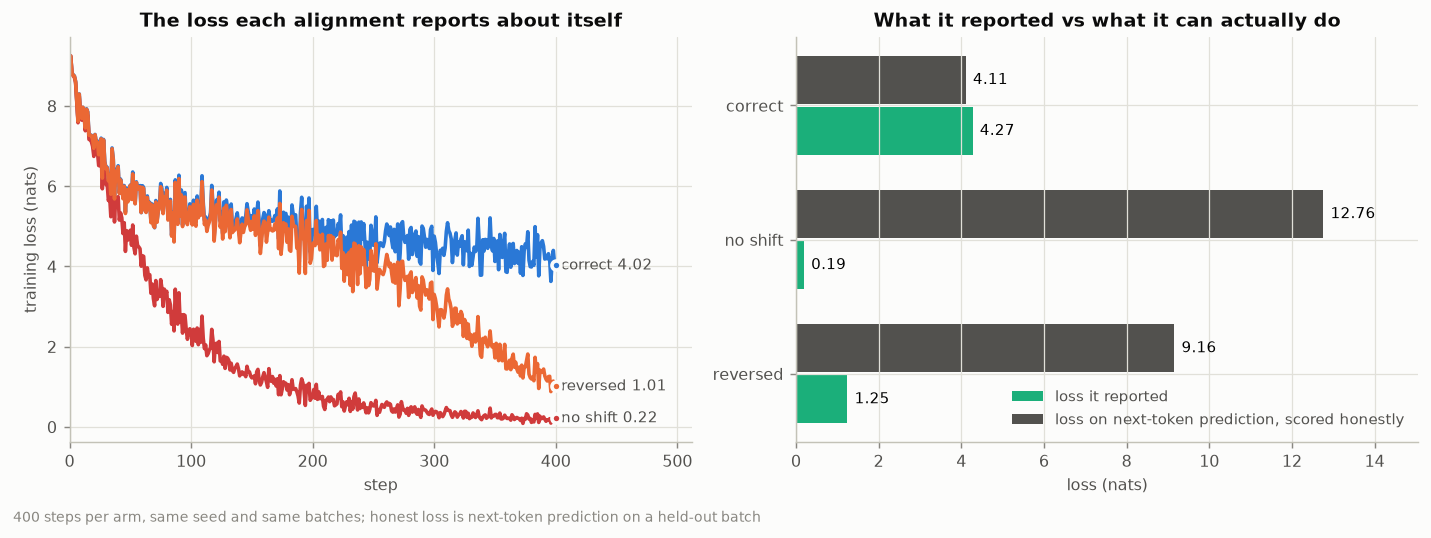

In [4]:
r2 = show("e2_shift")

## 3 · Mask padding, and the count changes

# 3 · Mask padding, and watch the denominator move

## The count changes

One batch, `B=8`, `T=128`. The rows hold [128, 93, 57, 39, 26, 46, 48, 26] real tokens, so
55.2% of the slots are padding.

| what the loss counts        | contributing tokens | loss (untrained) | denominator            |
| --------------------------- | ------------------: | ---------------: | ---------------------- |
| no mask — every pair counts |                1016 |           9.2625 | B × (T-1)              |
| padding masked out          |                 455 |           9.2497 | sum of the mask        |
| masked, wrong denominator   |                1016 |           4.1423 | B × (T-1), incorrectly |

**1016 → 455**, a drop of
561 pairs. That is the deliverable, and it is the only part of
this that is visible at initialisation.

The denominator is not a constant you can hard-code, either — it is a property
of the batch:

| batch | contributing | of B × (T-1) | fraction real |
| ----: | -----------: | -----------: | ------------: |
|   100 |          637 |         1016 |         62.7% |
|   101 |          616 |         1016 |         60.6% |
|   102 |          615 |         1016 |         60.5% |
|   103 |          531 |         1016 |         52.3% |
|   104 |          520 |         1016 |         51.2% |
|   105 |          575 |         1016 |         56.6% |

Divide by `B × (T-1)` and the loss is multiplied by that last column, which
moves every step. The third row of the first table is that bug on this batch:
4.1423 instead of 9.2497,
-55.2%
low, for a sum that was computed correctly.

## Why it matters more than dilution

Two models, 400 steps, same seed, same batches. One boolean apart.

| arm            | loss it reports | loss on real tokens | mean P(PAD) | top-1 is PAD |
| -------------- | --------------: | ------------------: | ----------: | -----------: |
| masks padding  |          4.5673 |              4.8850 |       0.00% |         0.0% |
| counts padding |          2.7219 |              4.9542 |      49.54% |        49.3% |

**The broken arm reports the better number.** 2.7219 against
4.5673 — it looks
40% better trained.

**On real tokens it is worse.** 4.9542 against
4.8850, a gap of
+0.0692 nats, both scored identically on
the same held-out batch.

Put those two rows next to each other and the shape of the bug is clear. The
reported loss is wrong by
**40%**. The model is
worse by **1.4%**. The number
on the dashboard is off by roughly
29×
more than the model is damaged — which is why this survives code review. Nobody
is looking for a bug that makes the loss *better*.

**Because that is where its capacity went.** It puts
49.54% of its probability mass on PAD and names
PAD as its top prediction at 49.3% of
positions, against 0.00% and
0.0% for the arm that never scored it. PAD
is the easiest token in the vocabulary — it is perfectly predictable from
position alone — so the loss falls fastest by learning it, and a loss that falls
is exactly what the run looks like it wants.

Note that attention was masked correctly in **both** arms: no position ever
attended to a padded key. The bug is entirely in the mean, in one line, several
hundred lines away from the attention mask that is doing its job.


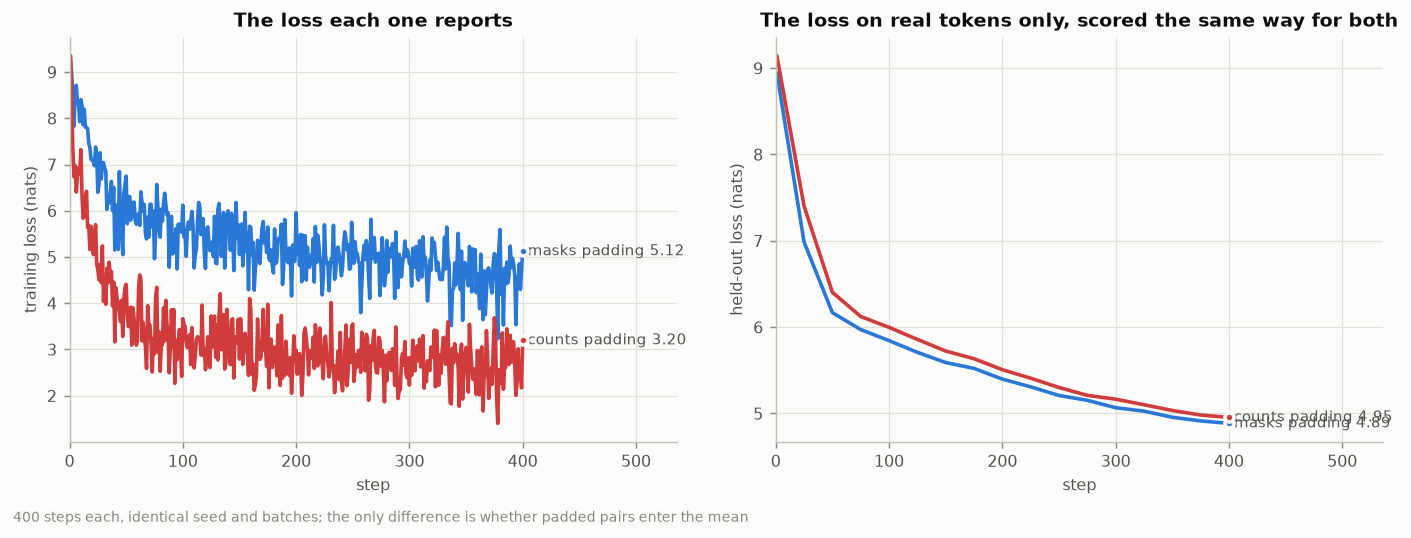

In [5]:
r3 = show("e3_padding")

## 4 · Pack two documents, mask the join

# 4 · Two documents in one sequence, and the join between them

## The join, read as text

Document A ends and document B begins inside one row. Decoded either side of
position 32:

> …'-@ the @-@ counter pain<eos>' **`<eos>`** … 'rack , composed by chiptune musician Y'…

| pos i | input token | target token | input's doc | target's doc | in the loss?   |
| ----: | ----------- | ------------ | ----------- | ------------ | -------------- |
|    28 | `ter`       | ` p`         | doc 0       | doc 0        | kept           |
|    29 | ` p`        | `ain`        | doc 0       | doc 0        | kept           |
|    30 | `ain`       | `<eos>`      | doc 0       | doc 0        | kept           |
|    31 | `<eos>`     | `rac`        | doc 0       | doc 1        | **masked out** |
|    32 | `rac`       | `k`          | doc 1       | doc 1        | kept           |
|    33 | `k`         | ` ,`         | doc 1       | doc 1        | kept           |
|    34 | ` ,`        | ` composed`  | doc 1       | doc 1        | kept           |
|    35 | ` composed` | ` by`        | doc 1       | doc 1        | kept           |

Exactly one pair crosses the join. Both of its tokens are real text — nothing
here is padding, nothing is malformed — and the pair is still a lie: the last
token of one article does not predict the first token of the next.

## The loss before and after masking it

An untrained model first, so the count is visible on its own:
**1016 → 1008**
contributing pairs, loss 9.2833 →
9.2832. At initialisation the two numbers are
almost identical, because an untrained model finds the join no harder than
anything else. **This is the trap: at step 0 the bug is invisible.**

After 400 steps on packed data:

| docs per row | pairs at a join | loss, join counted | loss, join masked | difference | mean loss *at* the join |
| -----------: | --------------: | -----------------: | ----------------: | ---------: | ----------------------: |
|            2 |           0.79% |             4.4037 |            4.3867 |    +0.0170 |                  6.5495 |
|            4 |           2.36% |             5.0088 |            4.9610 |    +0.0479 |                  6.9867 |
|            8 |           5.51% |             5.3450 |            5.2618 |    +0.0832 |                  6.7710 |
|           16 |          11.81% |             5.6081 |            5.4850 |    +0.1231 |                  6.5276 |

## Explaining the difference

**The difference is small and the cause is large.** At two documents per row the
join is 0.79% of the pairs and moves the reported
loss by only +0.0170 nats. Read that as reassuring and you have
misread it. The mean loss *at* the join is **6.5495** nats
against **4.3867** inside a document — the crossing pairs are
1.5× harder, and they are the hardest
pairs in the batch by a wide margin. They are diluted, not benign.

**Dilution is a property of the packing, not of the bug.** Pack sixteen
documents per row instead of two — which is what a 4K or 8K context does to a
corpus of short documents — and the same mistake moves the loss by
+0.1231 nats, 7× more,
because 11.81% of pairs now cross a join.
Nothing about the error changed. Only how often it is committed.

(Both columns rise with density for a reason that is not the bug: more
documents in a fixed 128 tokens means shorter fragments, so every position has
less context to work with. That is why the honest comparison is the difference
between the two columns and not the level of either.)

**And the loss is the least of it.** Every crossing pair is a gradient telling
the model that unrelated text follows `<eos>`. The model cannot learn that,
because it is not true, so it learns the next best thing: that after `<eos>`
anything can happen. That is capacity spent on making the model *less* certain,
and it is spent at exactly the position where a document boundary should be the
most informative token in the sequence.

The fix costs one comparison — `doc_id[i] == doc_id[i+1]` — and drops
8 pairs out of
1016. If the attention mask is also
document-aware (session 6), the two masks must agree: a position that cannot
*see* the previous document must not be scored as though it could.


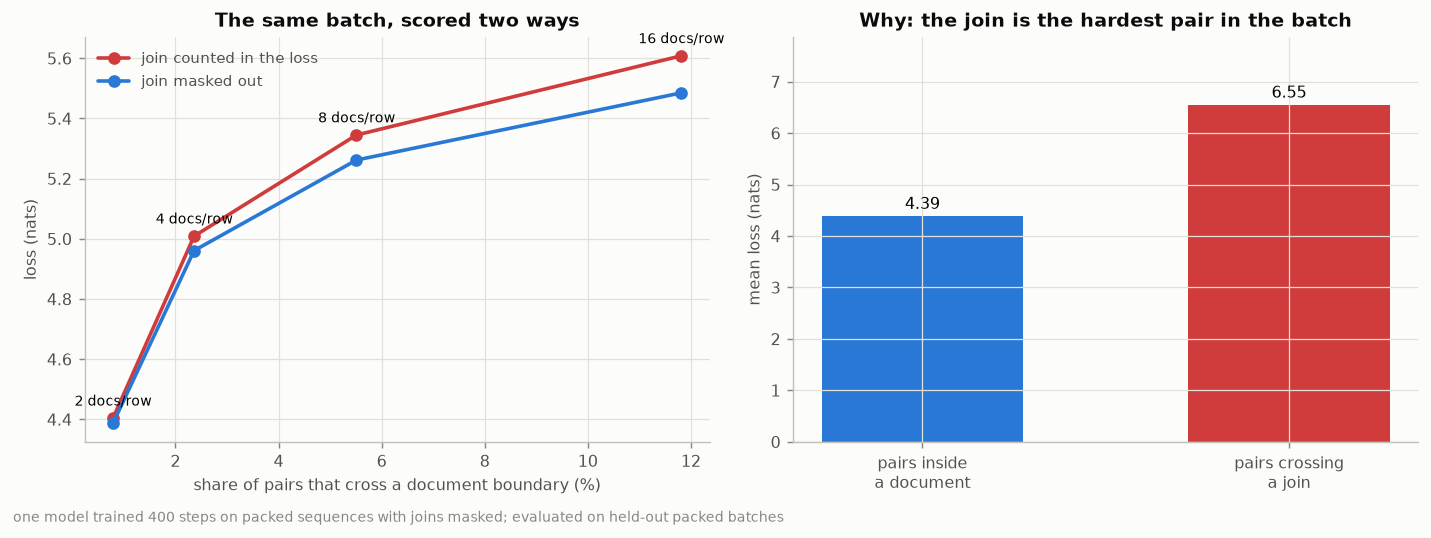

In [6]:
r4 = show("e4_packing")

## 5 · Perplexity of an untrained model ≈ vocabulary size

# 5 · Perplexity, and the cheapest sanity check there is

perplexity = exp(mean loss) — "how many equally likely options is the model
effectively choosing between at this token?"

## The anchor, exactly

A model that knows nothing should spread its probability evenly over the whole
vocabulary. Feed the loss a genuinely uniform logits tensor and it returns the
anchor to the last decimal it has:

| | |
|---|---|
| vocabulary | **10,002** |
| ln(V) | **9.210540** nats |
| loss from uniform logits | **9.210541** nats |
| perplexity from uniform logits | **10,002.00** |

The two agree to 6 decimal places, which is
what it means for the anchor to be a definition rather than an observation.

## Where the real untrained model sits

|                | at initialisation |
| -------------- | ----------------: |
| loss           |       9.2563 nats |
| perplexity     |            10,470 |
| vocabulary     |            10,002 |
| perplexity / V |             1.047 |

**Perplexity 10,470 against a vocabulary of
10,002** — 104.7% of it. The run may
proceed.

The small excess is not noise, and it is worth accounting for rather than
tolerating. At initialisation the logits are not exactly uniform: they have a
standard deviation of 0.3184, because the head is
initialised at std 0.02 and reads a 256-wide hidden state. For
logits with spread σ, `E[logsumexp(z)] ≈ ln V + σ²/2`, so the expected loss is

    ln V + σ²/2 = 9.2105 + 0.0507 = 9.2612

against a measured **9.2563**, out by
0.0049 nats. Nothing was fitted. A random head
sits slightly *above* ln(V), never below — so a first step **below** the anchor
is the alarming direction, and it is the direction every bug in this session
pushes it.

## What the check catches, and what it does not

Five harnesses, scored once, before any training. Pass = perplexity within a
factor of two of V.

| harness                       |   loss | perplexity | step-0 check | why                                                      |
| ----------------------------- | -----: | ---------: | ------------ | -------------------------------------------------------- |
| correct harness               | 9.2563 |     10,470 | pass         | lands on the anchor                                      |
| targets not shifted           | 9.2443 |     10,345 | pass         | an untrained model cannot copy yet, so this passes       |
| targets shifted backwards     | 9.2491 |     10,395 | pass         | same reason -- it passes, and it is still broken         |
| padding counted in the mean   | 9.3214 |     11,175 | pass         | padding is not yet predictable either                    |
| masked sum, wrong denominator | 6.5420 |        694 | **CAUGHT**   | caught immediately: the sum is right, the divisor is not |

**It catches the denominator instantly.** A correct sum divided by `B × (T-1)`
reports a perplexity of 694
against a vocabulary of 10,002 — a model that has not seen a single
gradient claiming to have narrowed 10,002 options down to
694.
That is impossible, it costs one forward pass to see, and it is free.

**It does not catch the shift, at step 0.** Both broken alignments pass, and
they pass for an honest reason: copying is a *learned* skill. An untrained model
cannot copy its input any better than it can predict the future, so at
initialisation all three alignments sit on the anchor together.

They separate within twenty steps — the figure's left panel — and by step
60 the no-shift run is at 4.27 nats
(perplexity 71.4) while the correct run is at
6.01. A perplexity of 71.4
after 60 steps on a 10k vocabulary is not a good run; it is a
different task. So the check is worth running as *"is the loss falling faster
than any real model could learn?"*, not only as a step-0 assertion.

**And nothing about padding.** Counting padding passes cleanly at step 0,
because PAD is not yet predictable either. Deliverable 3 is not covered by this
check and needs its own — the contributing-token count.

## One caution: perplexity is per *token*

Our tokenizer packs 2.85 bytes into the average
token on this sample. A tokenizer that split the same text into twice as many
tokens would be asked an easier question at each step and would report a better
perplexity for an identical model.

Bits per byte normalises by something the tokenizer cannot move:

    bpb = loss × tokens / (bytes × ln 2) = 4.6831

Comparable across tokenizers; perplexity is not. Within one tokenizer, which is
the whole of this session, perplexity is the more readable of the two.


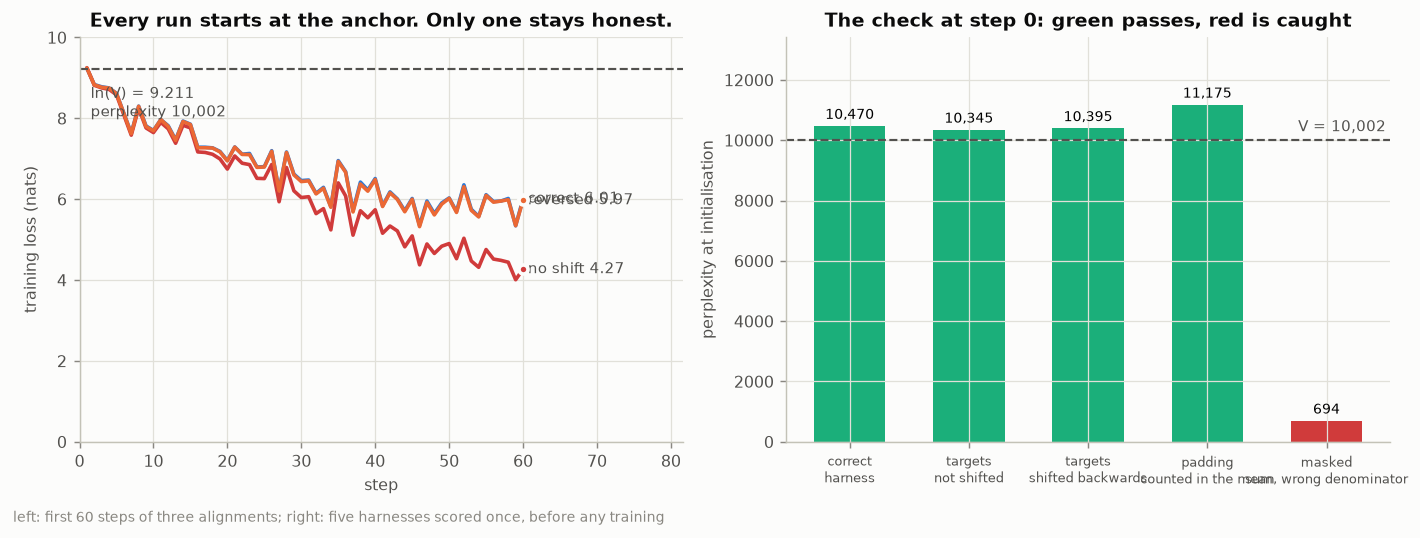

In [7]:
r5 = show("e5_perplexity")

## 6 · Tied against untied head

# 6 · Tied against untied, on this configuration

`V = 10,002`, `D = 256`, 4 blocks.

| parameter group                  |        untied |                tied |
| -------------------------------- | ------------: | ------------------: |
| input embedding `tok_emb` [V, D] |     2,560,512 |           2,560,512 |
| position embedding [max_seq, D]  |        65,536 |              65,536 |
| 4 transformer blocks             |     3,213,568 |           3,213,568 |
| output head `head` [V, D]        |     2,560,512 | 0 - the same tensor |
| **total**                        | **8,400,128** |       **5,839,616** |

**Tying saves 2,560,512 parameters, 30.5%
of the model** - 9.8 MiB of fp32 weights, and three times
that once AdamW's two moments are counted. The head alone is
30.5% of the untied model: the single largest
tensor in it, and 80% of the
size of all 4 transformer blocks put together
(2,560,512 against 3,213,568). One matrix, no
attention in it, weighing nearly as much as the entire depth of the model.

## Does the saving cost anything?

| arm    | parameters | final training loss | held-out loss |
| ------ | ---------: | ------------------: | ------------: |
| untied |  8,400,128 |              4.2748 |        4.1085 |
| tied   |  5,839,616 |              4.3986 |        4.2360 |

Same seed, same batches, 400 steps. The tied model is
30.5% smaller and lands
+0.1275 nats behind on held-out loss - a real cost, and larger than this run's step-to-step noise.

Read that as measured rather than as a verdict on tying: the 2,560,512 parameters tying removes were doing something here, and the 30.5% saving is not free. One pair of
400-step runs at `D=256` is not an ablation, and the published result
that tying "often helps quality" comes from models where the head is a far
larger share of the budget and the data is far larger relative to it. What this
run does establish is the direction of the trade on *this* configuration: the
30.5% is bought, not found.

The coupling is the real cost and it does not show up in a loss curve: the
vector that means *"this token just arrived"* is forced to be the vector that
means *"predict this token"*. Those are different jobs.

## The same subtraction at V5's width

|                                 |                       V5 |
| ------------------------------- | -----------------------: |
| vocabulary                      |                  131,072 |
| d_model                         |                    4,096 |
| output head, V x D              | **536,870,912** (536.9M) |
| as bf16 weights                 |                 1.00 GiB |
| session 7's factored input side |       33,554,432 (33.6M) |
| head / input side               |                **16.0x** |

At this width tying would save 536.9M parameters - and it
is not available. Session 7 replaced the dense `[V, D]` input table with a byte
codec plus one 33.6M projection, so there is no
input embedding matrix left to tie *to*. You cannot share rows with a thing that
has no rows.

That is the shape of the problem this session leaves open: the front door was
factored and won 93.75%, and the back door is still a dense
536.9M matrix, 16.0x the
size of the input side that replaced it. The standard escape is closed, so the
escape has to be a factored head - and that is an ablation nobody has run for a
byte-codec input side.


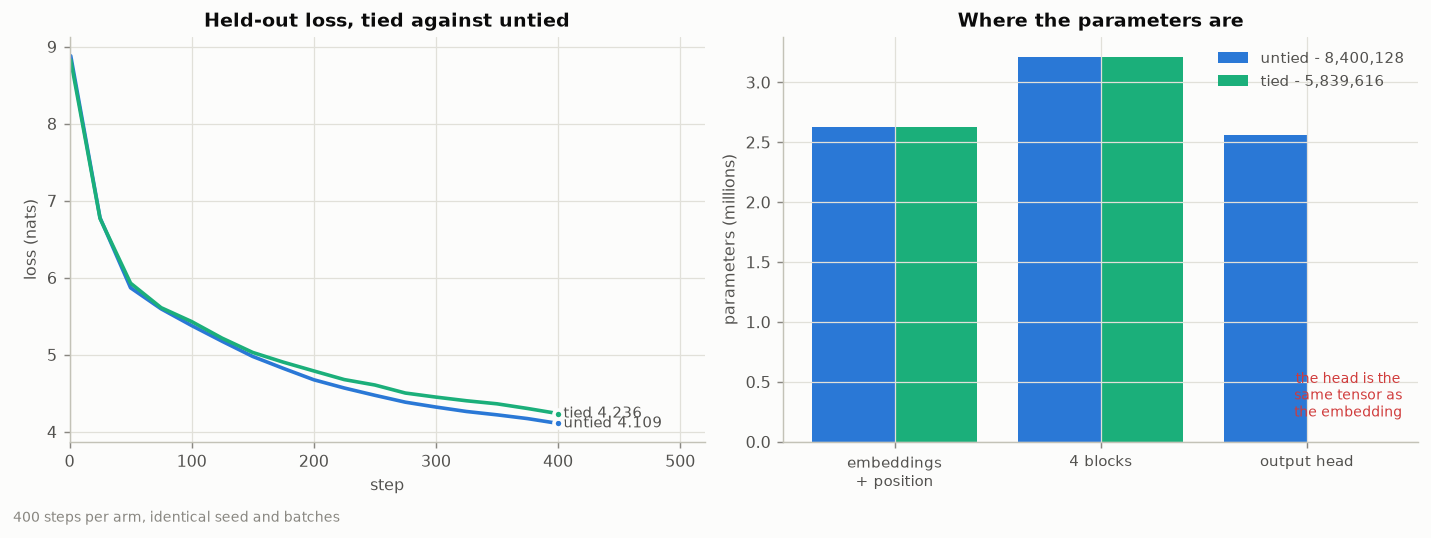

In [8]:
r6 = show("e6_tying")

## 7 · Peak memory: ordinary against chunked cross-entropy

# 7 · Peak memory: ordinary cross-entropy against a chunked one

`B=16`, `T=256`, `V=10,002`: **4,080 predictions**, so the logits are
4,080 x 10,002 x 4 B = **155.7 MiB** if held whole.

## The two numbers

| implementation | peak live tensors (loss step, fwd + bwd) |
| -------------- | ---------------------------------------: |
| ordinary `F.cross_entropy(logits)` | **624.5 MiB** |
| chunked, 512 rows at a time, recomputed in backward | **86.1 MiB** |
| **ratio** | **7.25x** lower |

## Is it the same loss?

| | ordinary | chunked | |diff| |
| - | -: | -: | -: |
| loss | 9.261488 | 9.261488 | 0.00e+00 |
| grad wrt hidden, max abs | | | 7.28e-12 (scale 2.46e-05) |
| grad wrt head weight, max abs | | | 2.09e-07 (scale 2.90e-01) |
| contributing tokens | 4080 | 4080 | |

Same value and same gradients up to float rounding, so the saving is not bought
with a different objective.

## Chunk-size sweep

| chunk rows | peak MiB | ratio vs ordinary | one chunk's logits MiB |
| ---------: | -------: | ----------------: | ---------------------: |
|         64 |     37.4 |            16.71x |                    2.4 |
|        128 |     42.2 |            14.80x |                    4.9 |
|        256 |     56.8 |            10.99x |                    9.8 |
|        512 |     86.1 |             7.25x |                   19.5 |
|       1024 |    144.8 |             4.31x |                   39.1 |
|       2048 |    262.0 |             2.38x |                   78.1 |

Peak grows roughly linearly with the chunk: what is alive at once is one chunk's
logits plus its softmax and gradient copies, on top of a fixed part (hidden
states, head weight and its gradient).  Ordinary cross-entropy is the same thing
with the "chunk" equal to every prediction in the batch: it holds about four
logits-sized tensors at once (4.0x the 156 MiB
logits: logits, softmax, their gradient, and autograd's copies).

## Cross-checks

* **Full training step** (embedding -> gradients, 4 blocks):
  ordinary 816.4 MiB, chunked
  434.3 MiB, **1.88x**.  Smaller than the
  loss-step ratio because the blocks' activations are common to both.
* **Independent measurement**, fresh CPU process, peak RSS growth:
  ordinary 637 MiB, chunked 202 MiB
  (3.15x).  It agrees on direction and on
  "several times lower" but not on the ratio: RSS is coarse (allocator retention,
  page granularity, and the CPU allocator's reuse of freed blocks), so the tracker's
  live-tensor number is the one reported.

## How the chunked version works

1. Gather only contributing positions, so padded positions never get logits.
2. For each chunk of `512` rows: `logits = h_chunk @ W.T`, sum of cross-entropy, done.
3. Wrap each chunk in `torch.utils.checkpoint`: its logits are freed after the
   forward and recomputed in backward.  Without it autograd keeps every chunk's
   logits alive and the peak is back where it started.
4. Sum the chunks' *sums* and divide once by the total count.  Averaging chunk
   averages would be wrong whenever chunks hold different token counts.

The price is one extra `h @ W.T` per chunk in backward: memory is bought with FLOPs.


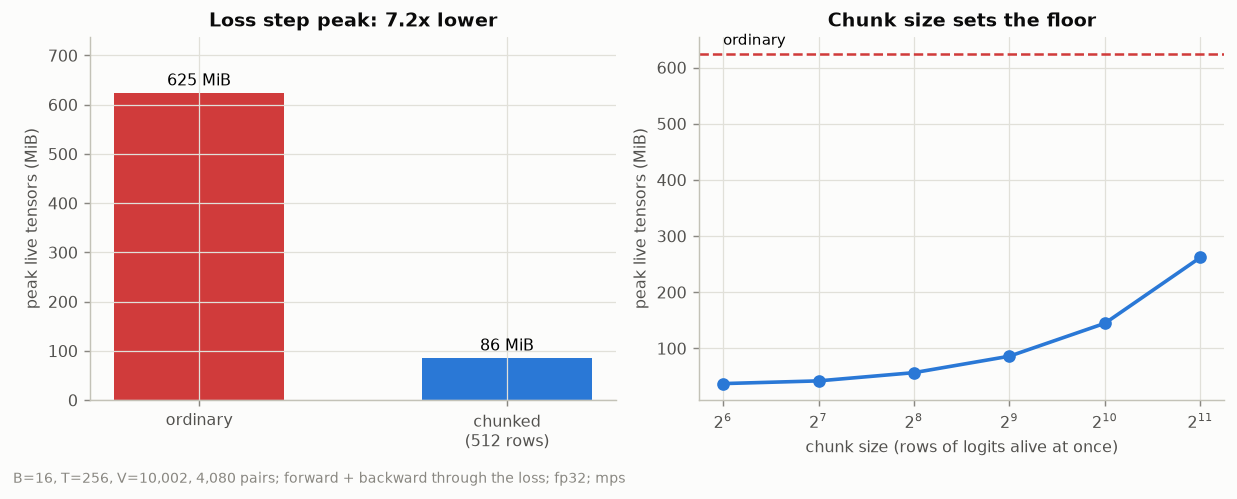

In [9]:
r7 = show("e7_memory")

## Part 2 · One extra head, predicting token `t+2`

# Part 2 · One extra head, predicting token t+2

One trunk, two untied heads on the same final hidden state. Head 1 scores
position `i` against token `i+1`; head 2 against token `i+2` (alignment printed in
experiment 2's style: the last two positions of each row have no t+2 target and are
dropped). Training loss = `L1 + L2`. 1500 steps, `B=8`, `T=128`, AdamW
lr 0.0003, 3 seeds (mean ± std across seeds). Held-out = 32 fresh
validation rows, honest mask.

## The numbers

| | head 1 (t+1) | head 2 (t+2) | sum L1 + L2 |
| - | -: | -: | -: |
| untrained (held-out) | 9.244 ± 0.011 | 9.252 ± 0.032 | 18.496 |
| **trained, held-out** | **3.755 ± 0.017** | **4.726 ± 0.006** | **8.481 ± 0.020** |
| trained, train stream (last 100 steps) | 3.588 ± 0.042 | 4.617 ± 0.039 | 8.205 |

Reference points: ln V = 9.211; unigram entropy of the data =
6.310 nats (a model that ignores context can do no better).

Head 2 finishes **0.971 ± 0.015 nats above head 1**
(held-out).

## Does the second head change the first?

| head 1 held-out loss | |
| - | -: |
| trained with head 2 (sum objective) | 3.755 ± 0.017 |
| trained alone | 3.715 ± 0.012 |

Difference +0.040 nats against a seed spread of
about 0.017.

## What happens to the second head's loss, and why

* **Identical for the first ~60 steps.** Both heads start at ≈ ln V (an untrained
  model cannot tell t+1 from t+2) and fall together to about the unigram entropy
  (6.31 nats). What is learned there (token frequencies)
  helps both targets equally, so the two curves lie on top of each other.
* **Then they separate, and the gap keeps growing.** Past the unigram level, head 1
  keeps falling steadily while head 2 flattens. L2 − L1 opens from 0 at step 50 to
  ≈ 0.6 by step 400, ≈ 0.9 by step 800 and 0.97 at step 1500
  (held-out), still widening slowly. In the second half of training head 1 gains far
  more per step than head 2.
* **Why head 2 is harder: it is predicting one more token blind.** After the trunk
  has seen tokens `0..i`, token `i+1` is constrained by grammar and local context.
  Token `i+2` depends on the same context *and* on the unobserved token `i+1`, so
  the uncertainty compounds. For a stationary source
  `H(x_{i+2} | x_{≤i}) ≥ H(x_{i+1} | x_{≤i})`, so a persistent gap is
  expected; it is not a bug. What head 1 learns from local structure (syntax,
  word completion after sub-word pieces) is exactly what head 2 cannot use.
* **The gap is not a floor yet.** At this model size and step count neither head is
  near its entropy, so the ≈ 1.0 nat gap is a snapshot, not the
  irreducible difference.
* **The extra head slightly taxes head 1**: it ends +0.040 nats
  worse than when trained alone. Small (but larger than the seed spread), because
  the trunk's capacity is now shared with a second objective.
* **Read the sum with care.** `L1 + L2` is dominated by the harder head, and it is
  not comparable with any single-head loss. That is why the two are reported
  separately.

![e8](e8_extra_head.png)


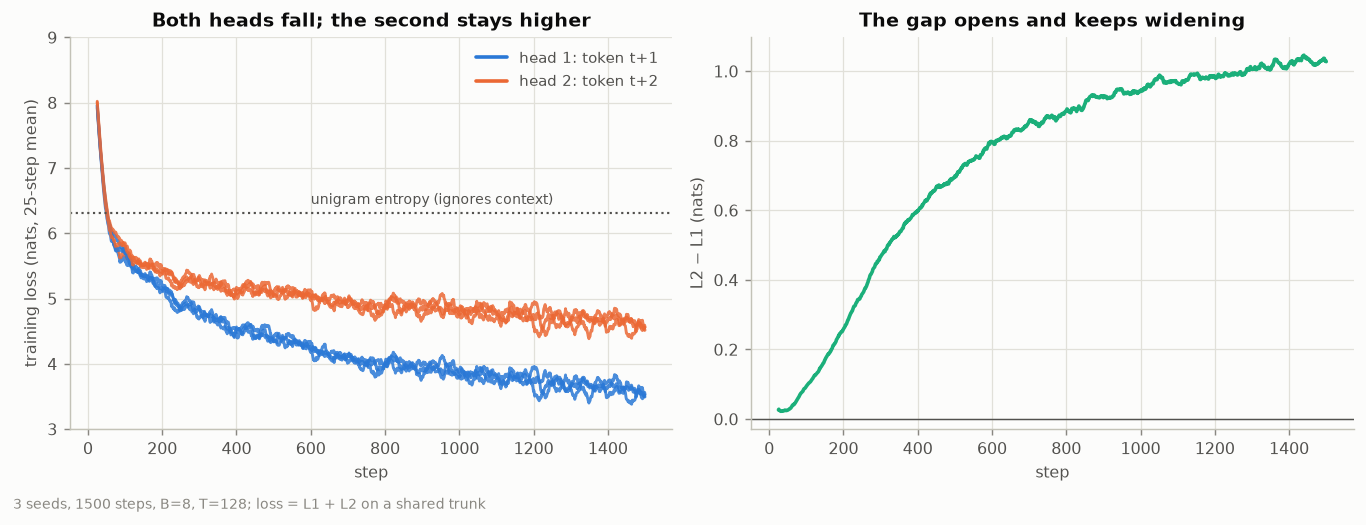

In [10]:
r8 = show("e8_extra_head", figure=True, md=True)

## The numbers, in one place

In [11]:
import json
R = lambda n: json.load(open(f"results/{n}.json"))
e2, e3, e4, e5, e6, e7, e8 = (R(n) for n in ["e2_shift", "e3_padding", "e4_packing", "e5_perplexity", "e6_tying", "e7_memory", "e8_extra_head"])
a = e8["aggregate"]
rows = [
 ("1 shapes",              "logits 4x128x10002 = 39.1x the hidden state (see table above)"),
 ("2 shift",               "reported loss, honest next-token loss: " + "; ".join(f"{k} {v['mean_last_20']:.2f}/{v['honest_next_token_loss']:.2f}" for k, v in e2["arms"].items())),
 ("3 padding",             f"contributing tokens {e3['counts']['pairs_before_masking']} -> {e3['counts']['pairs_after_masking']}"),
 ("4 packing",             f"loss {e4['untrained']['loss_unmasked']:.4f} -> {e4['untrained']['loss_masked']:.4f} untrained; after training {e4['density']['2']['loss_unmasked']:.4f} -> {e4['density']['2']['loss_masked']:.4f}"),
 ("5 perplexity",          f"{e5['untrained']['perplexity']:,.0f} vs V = {e5['anchor']['vocab_size']:,} ({e5['untrained']['perplexity_over_vocab']:.3f}x)"),
 ("6 tied vs untied",      f"{e6['counts']['untied_total']:,} vs {e6['counts']['tied_total']:,} (saves {e6['counts']['saved']:,}, {100*e6['counts']['saved_fraction']:.1f}%)"),
 ("7 peak memory",         f"ordinary {e7['ordinary']['peak_mib']:.0f} MiB vs chunked {e7['chunked']['peak_mib']:.0f} MiB = {e7['ratio_loss_step']:.2f}x"),
 ("Part 2 head 1 (t+1)",   f"{a['end_l1'][0]:.3f} held-out"),
 ("Part 2 head 2 (t+2)",   f"{a['end_l2'][0]:.3f} held-out"),
 ("Part 2 sum",            f"{a['end_sum'][0]:.3f}"),
]
for k, v in rows: print(f"{k:<22} {v}")

1 shapes               logits 4x128x10002 = 39.1x the hidden state (see table above)
2 shift                reported loss, honest next-token loss: correct 4.27/4.11; no shift 0.19/12.76; reversed 1.25/9.16
3 padding              contributing tokens 1016 -> 455
4 packing              loss 9.2833 -> 9.2832 untrained; after training 4.4037 -> 4.3867
5 perplexity           10,470 vs V = 10,002 (1.047x)
6 tied vs untied       8,400,128 vs 5,839,616 (saves 2,560,512, 30.5%)
7 peak memory          ordinary 625 MiB vs chunked 86 MiB = 7.25x
Part 2 head 1 (t+1)    3.755 held-out
Part 2 head 2 (t+2)    4.726 held-out
Part 2 sum             8.481
